In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from scipy.stats import ttest_ind, levene, shapiro
import calendar
import numpy as np
import xlrd as xlrd

In [ ]:
# Cargar todas las hojas del archivo
csv_file = "Cred_por_sector.csv"
leer_csv = pd.read_csv(csv_file) 

# Guardar cada hoja en un DataFrame separado
df_sector = leer_csv

# Mostrar para confirmar
print("Columnas cargadas:")
for nombre in leer_csv:
    print(f"- {nombre}")

Hojas cargadas:
- Fecha
- Sector E.
- Atlas
- Bancop
- Basa
- BNA
- BNF
- Citibank
- Continental
- Do Brasil
- Familiar
- GNB
- GNB Fusión
- Interfisa
- Itaú
- Regional
- Río
- Solar
- Sudameris
- UENO
- Visión
- Zeta
- Moneda


In [32]:
# Filtrar por sector AGRICULTURA
df_agricultura = df_sector[df_sector['Sector E.'] == 'AGRICULTURA'].copy()

# Convertir columna Fecha a datetime (agregando día)
df_agricultura['Fecha'] = pd.to_datetime(df_agricultura['Fecha'].astype(str) + '/01', format='%Y/%m/%d')

#Borramos la columna 'Sector E.' para evitar duplicados
df_agricultura.drop(columns=['Sector E.'], inplace=True)

In [33]:
# Transponer el DataFrame
df_nuevo = df_agricultura.melt(
    id_vars=["Fecha", "Moneda"],
    var_name="Banco",
    value_name="Credito"
)

In [34]:
# Reemplazar nombres de bancos fusionados y agrupar
df_nuevo["Banco"] = df_nuevo["Banco"].replace({
    "GNB Fusión": "GNB",
    "Regional": "Sudameris",
    "Visión": 'UENO'
})

# Agrupar por fecha, moneda y banco
df_nuevo = df_nuevo.groupby(["Fecha", "Moneda", "Banco"], as_index=False).sum()

# Crear df con moneda
df_con_moneda = df_nuevo.copy()

# Crear df sin moneda
df_nuevo_banco = df_nuevo.drop(columns=["Moneda"]).groupby(["Fecha", "Banco"], as_index=False).sum()

In [35]:
# Eliminar las filas donde todos los bancos tienen 0 en créditos
df_nuevo = df_nuevo[df_nuevo.drop(columns=["Fecha", "Moneda","Banco"]).sum(axis=1) != 0]

df_nuevo_banco = df_nuevo_banco[df_nuevo_banco.drop(columns=["Fecha", "Banco"]).sum(axis=1) != 0]

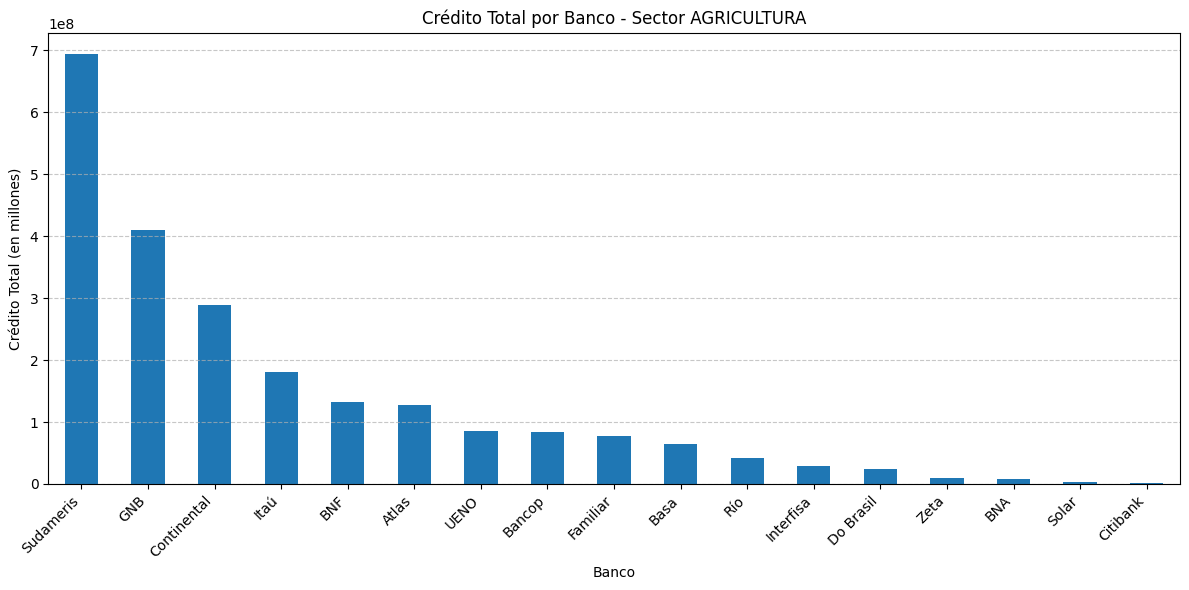

In [36]:
#Grafico de totales por banco
credito_total = df_nuevo.groupby("Banco")["Credito"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
credito_total.plot(kind='bar')
plt.title("Crédito Total por Banco - Sector AGRICULTURA")
plt.xlabel("Banco")
plt.ylabel("Crédito Total (en millones)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

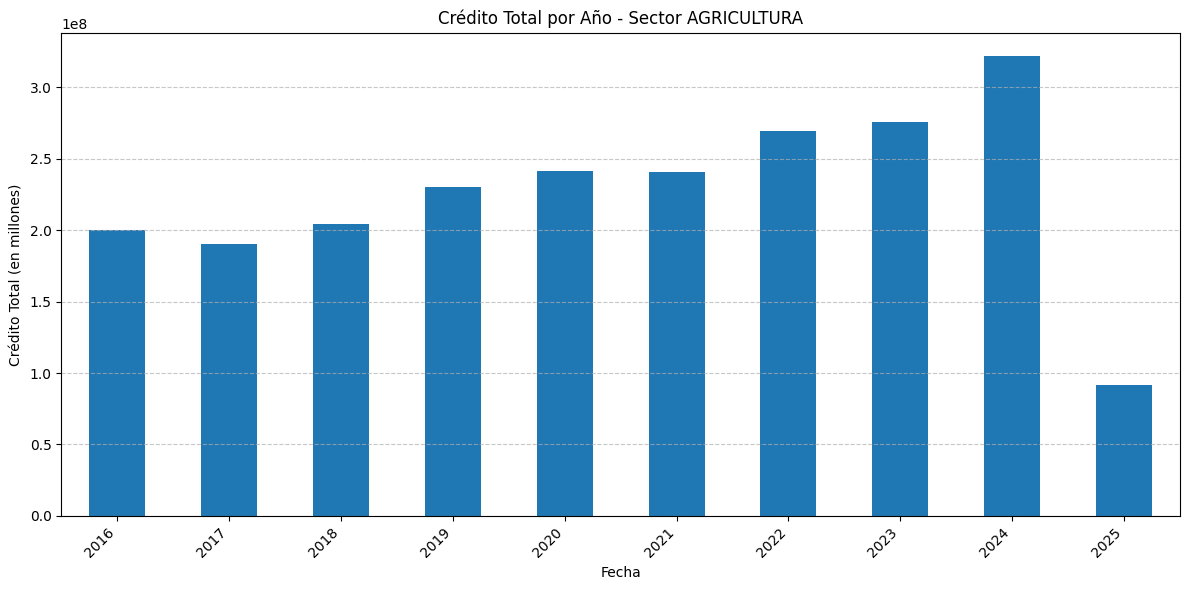

In [37]:
#Grafico de totales por año
df_year = df_nuevo.copy()
df_year['Anho'] = df_year['Fecha'].dt.year
credito_total = df_year.groupby("Anho")["Credito"].sum()
plt.figure(figsize=(12, 6))
credito_total.plot(kind='bar')
plt.title("Crédito Total por Año - Sector AGRICULTURA")
plt.xlabel("Fecha")
plt.ylabel("Crédito Total (en millones)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

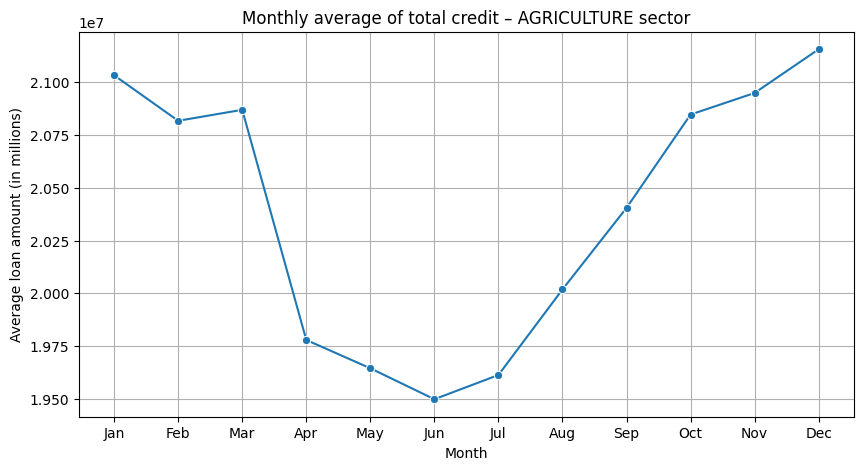

In [38]:
#Graficar promedios mensuales

serie_total = df_nuevo.groupby("Fecha")["Credito"].sum().reset_index()

serie_total["Mes"] = serie_total["Fecha"].dt.month
serie_total["Mes_nombre"] = serie_total["Fecha"].dt.strftime('%b')  # Nombre corto del mes

promedios_mensuales = serie_total.groupby("Mes_nombre")["Credito"].mean().reindex(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])

plt.figure(figsize=(10, 5))
sns.lineplot(x=promedios_mensuales.index, y=promedios_mensuales.values, marker="o")
plt.title("Monthly average of total credit – AGRICULTURE sector")
plt.xlabel("Month")
plt.ylabel("Average loan amount (in millions)")
plt.grid(True)
plt.show()

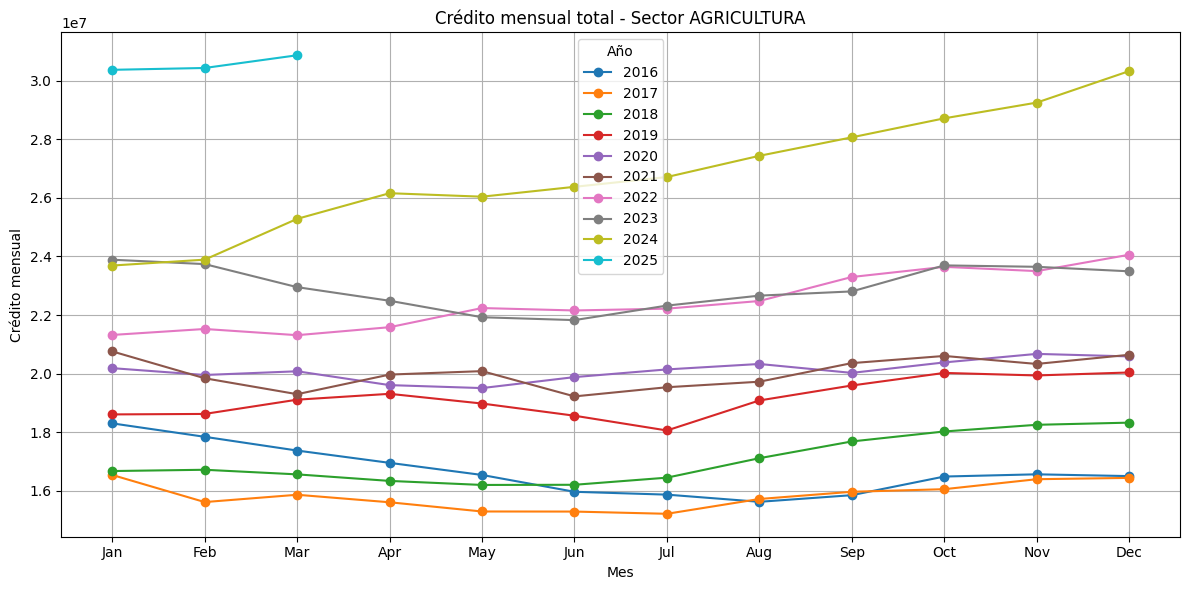

In [39]:
# Crear columna Año
serie_total["Año"] = serie_total["Fecha"].dt.year

# Pivot table: filas = Mes, columnas = Año, valores = suma de crédito
pivot = serie_total.pivot_table(index="Mes", columns="Año", values="Credito", aggfunc='sum')

# Etiquetas de los meses
meses_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Graficar
plt.figure(figsize=(12,6))
for año in pivot.columns:
    plt.plot(pivot.index, pivot[año], marker='o', label=str(año))

plt.xticks(ticks=range(1,13), labels=meses_labels)
plt.title("Crédito mensual total - Sector AGRICULTURA")
plt.xlabel("Mes")
plt.ylabel("Crédito mensual")
plt.legend(title="Año")
plt.grid(True)
plt.tight_layout()
plt.show()

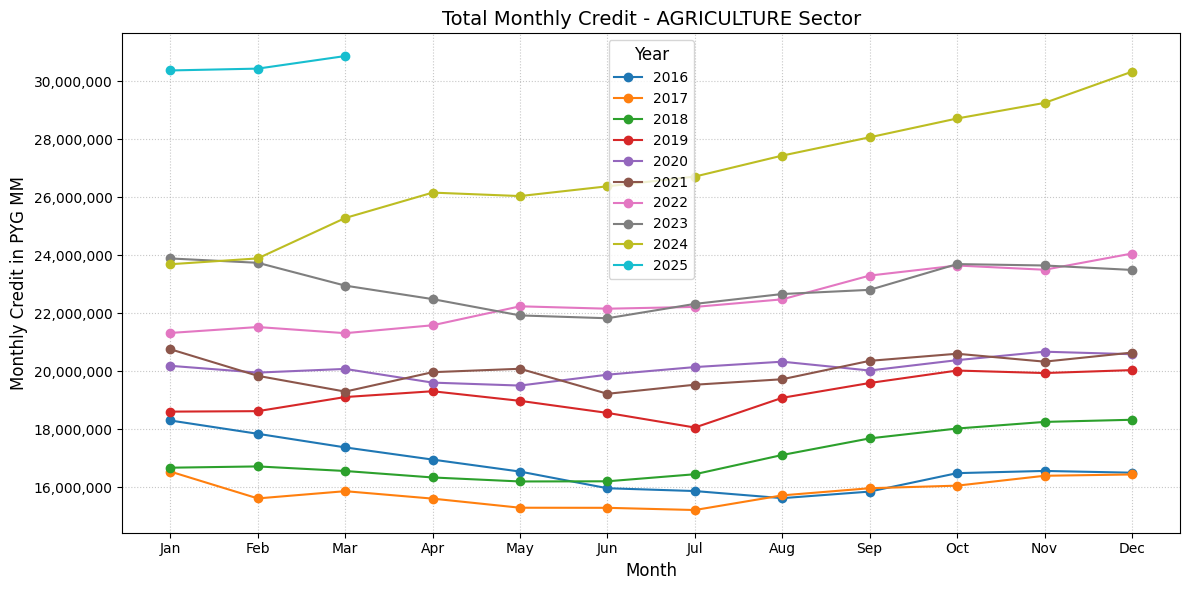

In [40]:
# Graficar
plt.figure(figsize=(12, 6))
for año in pivot.columns:
    plt.plot(pivot.index, pivot[año], marker='o', label=str(año))

# --- CAMBIO CLAVE AQUÍ: Ejes y título en inglés ---
plt.xticks(ticks=range(1, 13), labels=meses_labels)
plt.title("Total Monthly Credit - AGRICULTURE Sector", fontsize=14) # Título más descriptivo y en inglés
plt.xlabel("Month", fontsize=12) # Etiqueta del eje X en inglés
plt.ylabel("Monthly Credit in PYG MM", fontsize=12) # Etiqueta del eje Y en inglés
plt.legend(title="Year", fontsize=10, title_fontsize=12) # Leyenda con título en inglés
plt.grid(True, linestyle=':', alpha=0.7) # Grid más sutil

# Mejorar el formato del eje Y para grandes números
plt.ticklabel_format(style='plain', axis='y', scilimits=(0,0)) # Eliminar notación científica
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ','))) # Formato con comas

plt.tight_layout() # Ajusta el layout para evitar que los elementos se superpongan
plt.show()

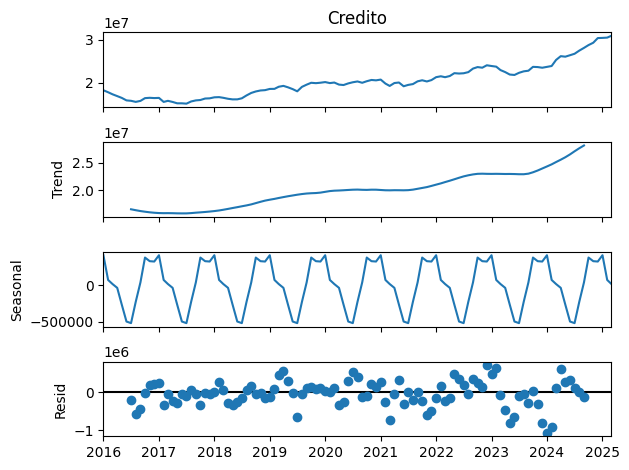

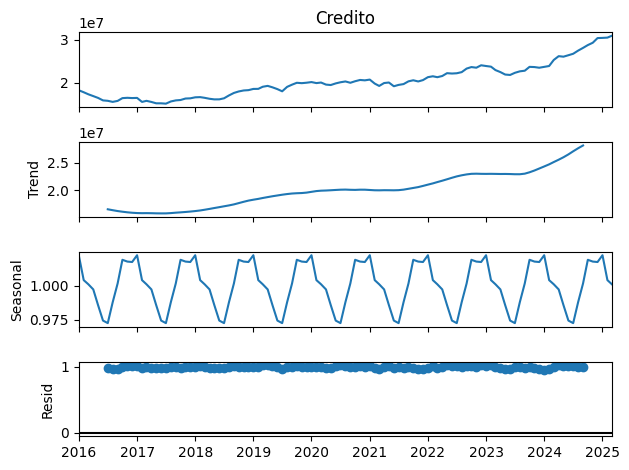

In [41]:
# Sumar todos los créditos por fecha
serie_total = df_nuevo.groupby("Fecha")["Credito"].sum().sort_index()

# Asegurarse de que la frecuencia sea mensual
serie_total = serie_total.asfreq("MS")  # MS = Month Start

# Descomposición aditiva
result = seasonal_decompose(serie_total, model="additive", period=12)

# Mostrar gráfica
result.plot()
plt.tight_layout()
plt.show()

# Prueba modelo multiplicativo
resultado_multi = seasonal_decompose(serie_total, model='multiplicative', period=12)
resultado_multi.plot()
plt.tight_layout()
plt.show()

In [42]:
#Prueba de estacionariedad
adf = adfuller(serie_total.dropna())
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value: {adf[1]:.4f}")

if adf[1] < 0.05:
    print("✅ La serie es estacionaria.")
else:
    print("⚠️ La serie NO es estacionaria.")

ADF Statistic: 1.6093
p-value: 0.9979
⚠️ La serie NO es estacionaria.


### Dado el aumento de la amplitud estacional a lo largo del tiempo y la mayor estacionariedad tanto de los componentes residuales como de los estacionales, el modelo de **descomposición multiplicativa** proporciona una representación más adecuada de la serie temporal

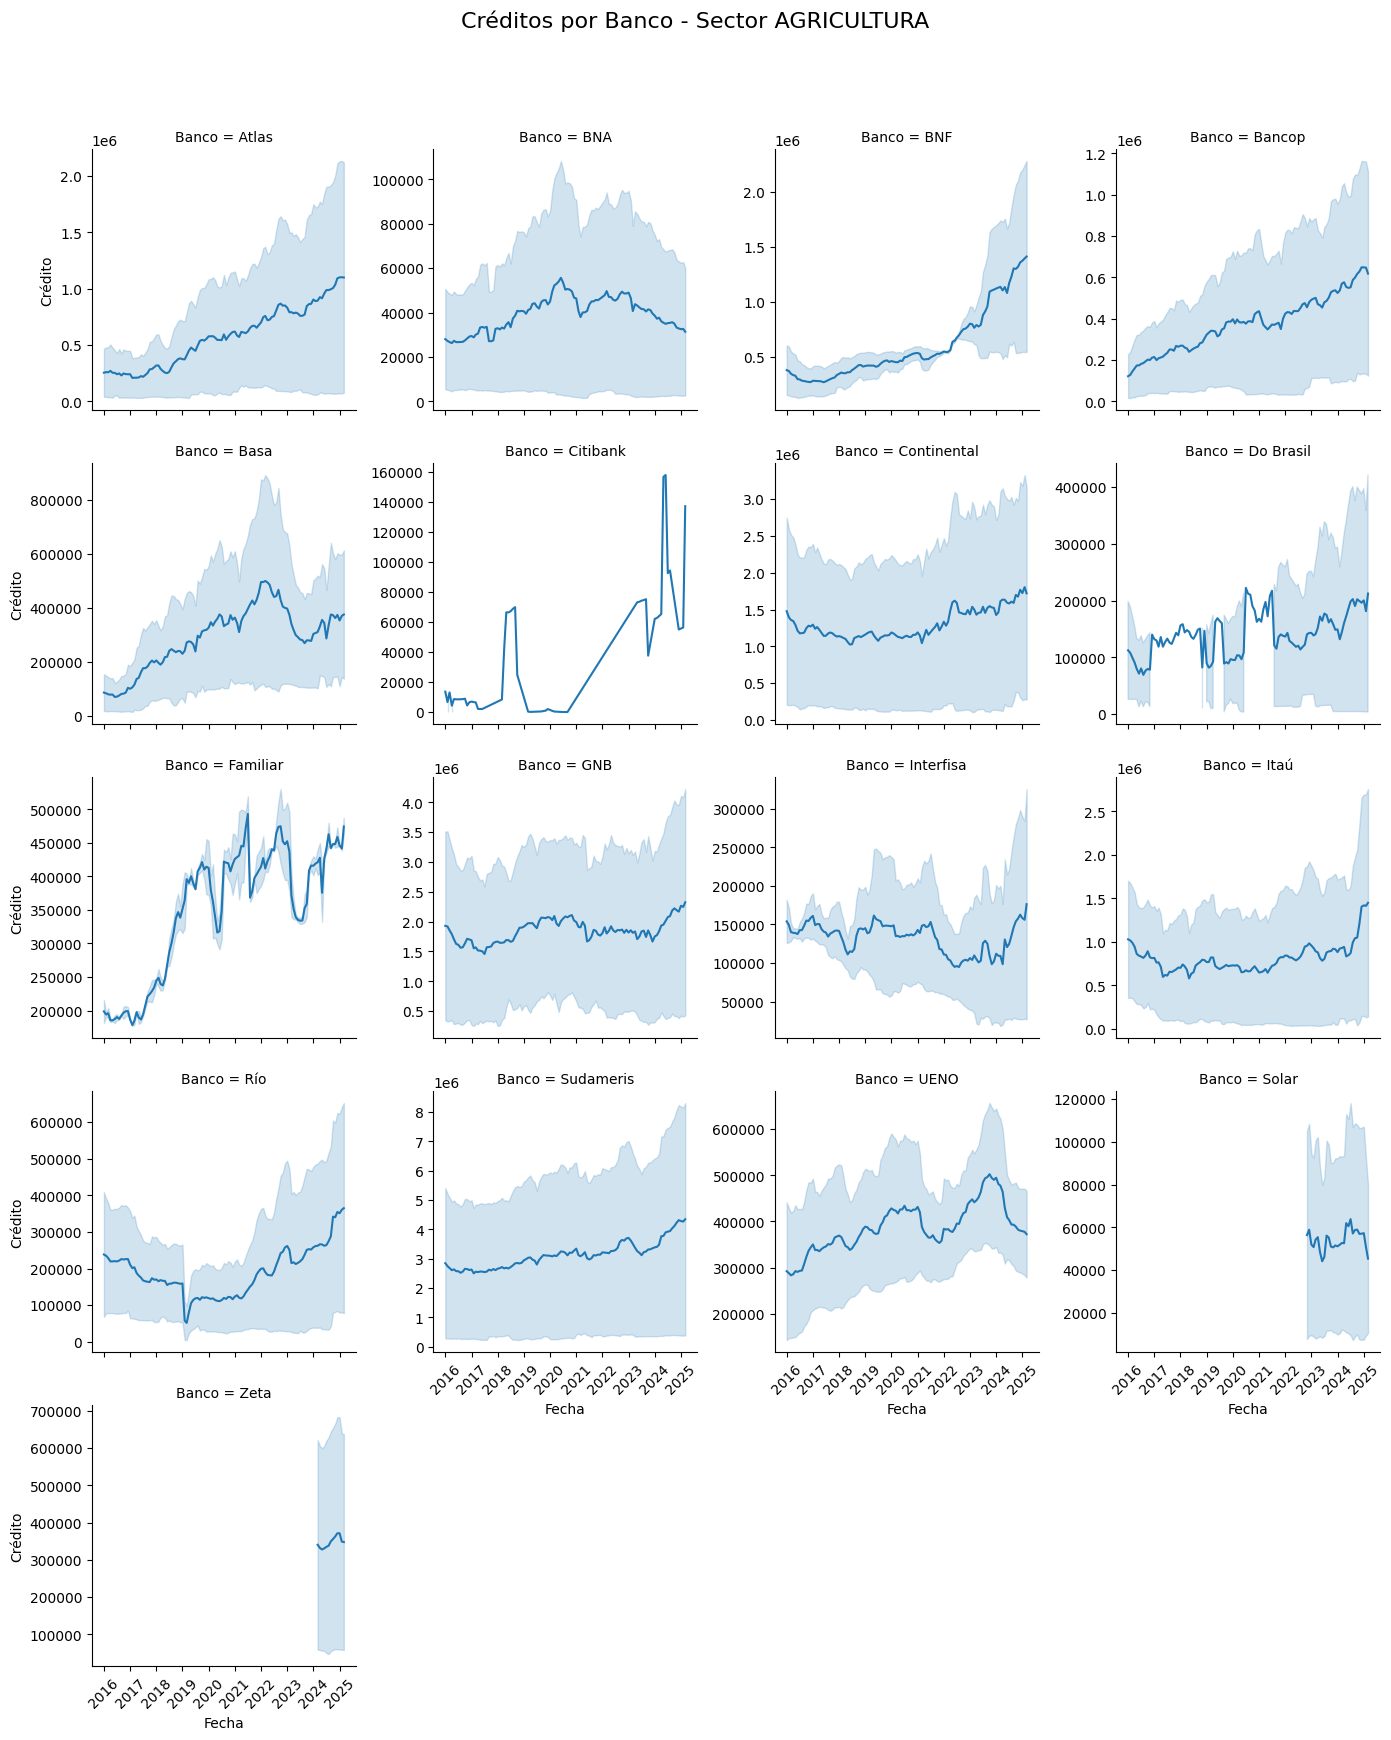

In [43]:
# Crear una gráfica por banco
g = sns.FacetGrid(df_nuevo, col="Banco", col_wrap=4, height=3.5, sharey=False)

# Mapear la serie temporal en cada panel
g.map_dataframe(sns.lineplot, x="Fecha", y="Credito")

# Mejorar etiquetas y rotación de fechas
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels("Fecha", "Crédito")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Créditos por Banco - Sector AGRICULTURA", fontsize=16)

plt.show()

### Analisis por moneda para ver si incluir o agrupar

In [44]:
# Analizar por moneda
df_nuevo.groupby('Moneda')['Credito'].describe()

,count,mean,std,min,25%,50%,75%,max
Moneda,,,,,,,,
ME,1645.0,1.204215e+06,1.582672e+06,93.452548,211105.829696,481625.588882,1.587106e+06,8.308422e+06
MN,1564.0,1.812390e+05,1.802187e+05,0.080919,37417.015328,107926.881986,2.939647e+05,8.146924e+05


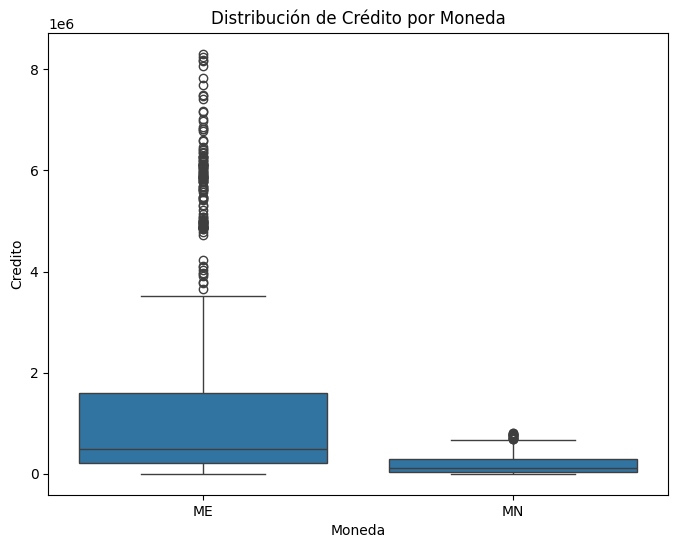

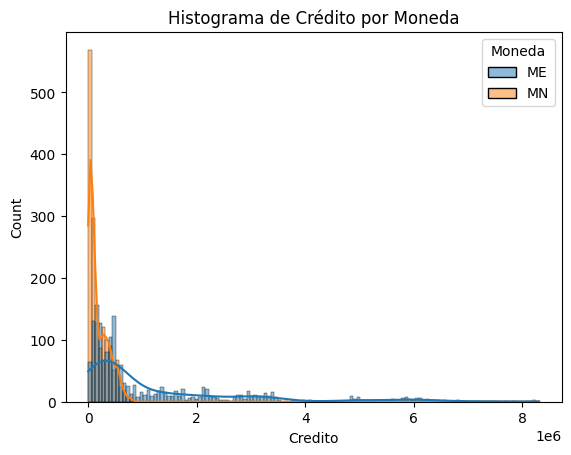

In [45]:
# Box plot de crédito por moneda
plt.figure(figsize=(8, 6))
sns.boxplot(x='Moneda', y='Credito', data=df_nuevo)
plt.title('Distribución de Crédito por Moneda')
plt.show()

# histogramas superpuestos/facetados
sns.histplot(data=df_nuevo, x='Credito', hue='Moneda', kde=True)
plt.title('Histograma de Crédito por Moneda')
plt.show()

### Comparación visual por bancos con mayores colocaciones en el Sector 

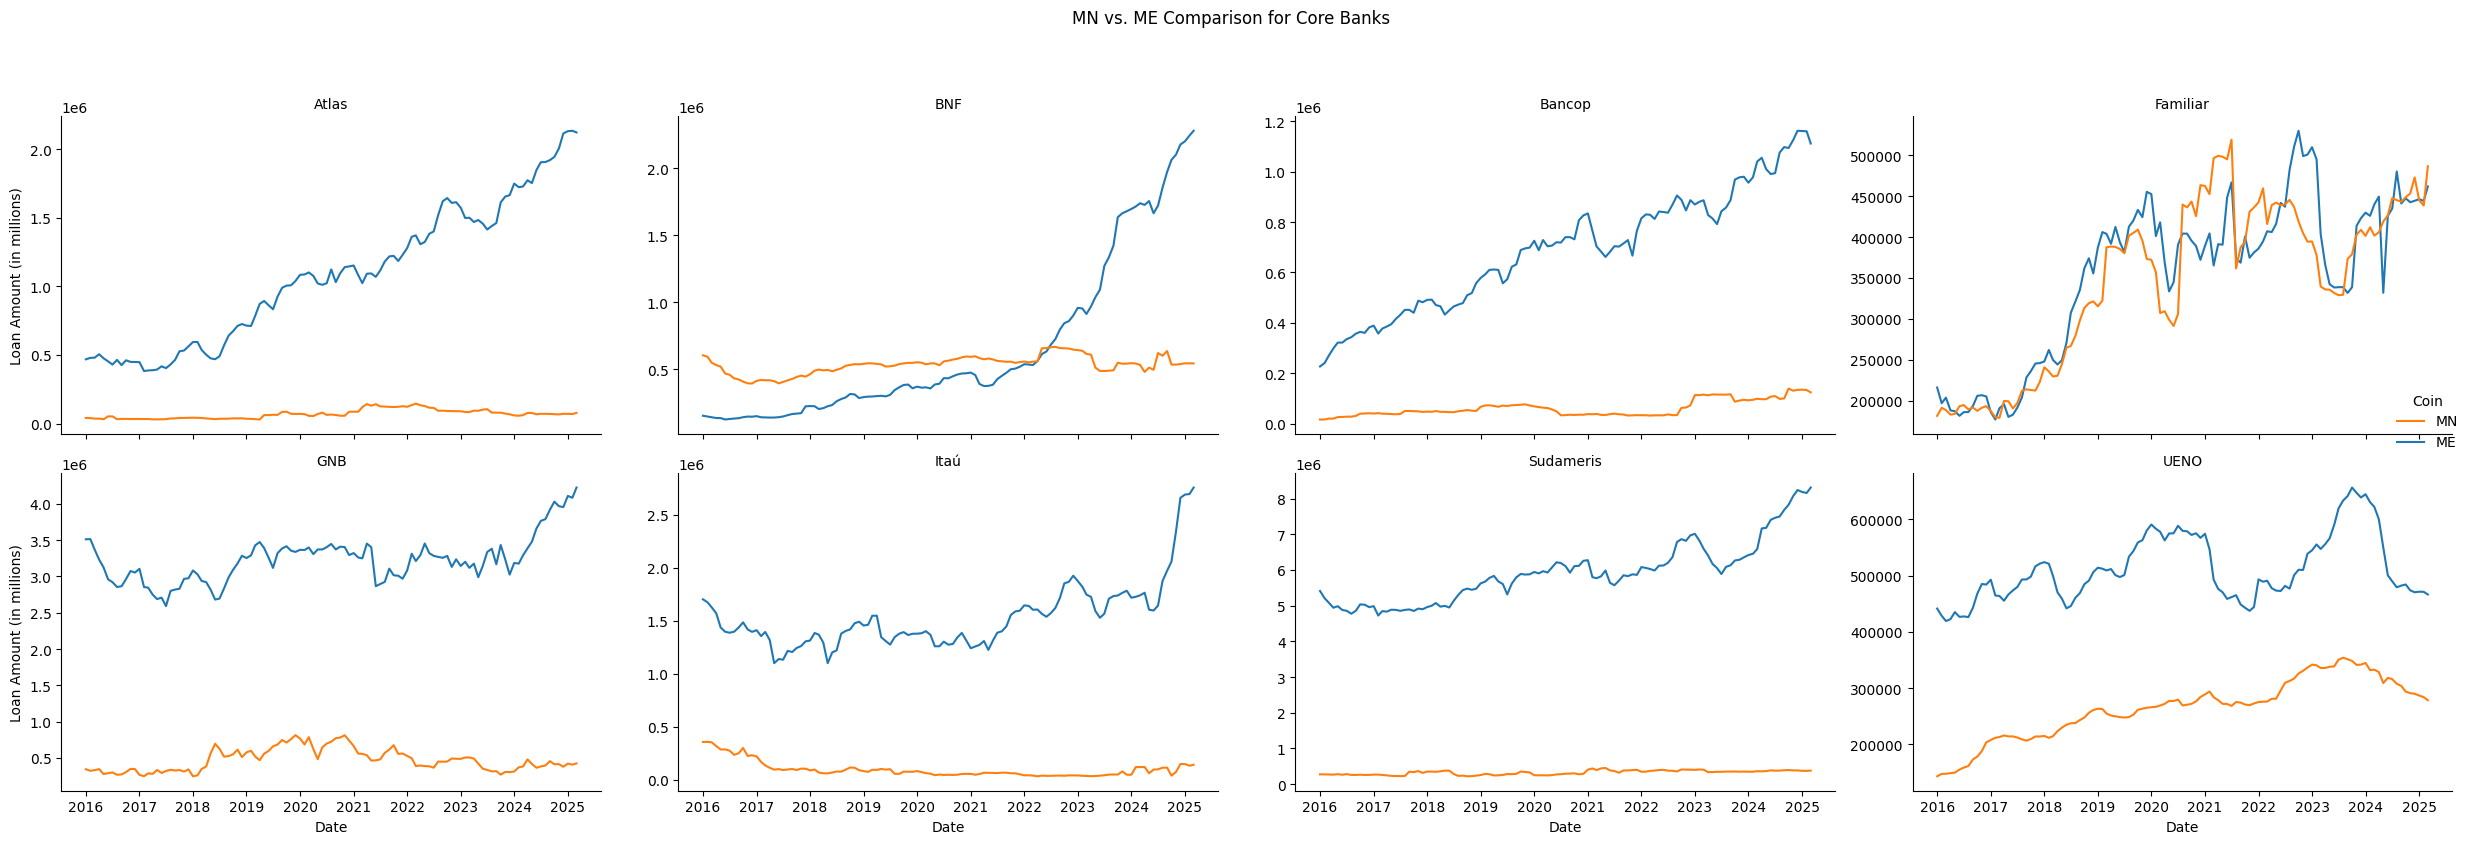

In [46]:
# Bancos clave
bancos_clave = ['Sudameris', 'GNB', 'Itaú', 'BNF', 'Atlas', 'UENO', 'Bancop', 'Familiar']

# Filtramos
df_clave = df_nuevo[df_nuevo['Banco'].isin(bancos_clave)]

# Graficamos
g = sns.FacetGrid(df_clave, col="Banco", hue="Moneda", height=4, aspect=1.5,col_wrap=4, sharey=False)
g.map(sns.lineplot, "Fecha", "Credito")
g.add_legend(title="Coin", label_order=["MN", "ME"])
g.set_titles("{col_name}")
g.set_axis_labels("Date", "Loan Amount (in millions)")

plt.suptitle("MN vs. ME Comparison for Core Banks", y=1.05)
plt.tight_layout()
plt.show()

### Considerando la magnitud del impacto de la Moneda, es mejor analizar series separadas para cada moneda (MN y ME)

In [47]:
# 1. Escalar FechaOrd
fecha_min = df_nuevo["Fecha"].min()
df_nuevo["FechaOrd_scaled"] = pd.to_datetime(df_nuevo["Fecha"]).map(lambda x: (x - fecha_min).days)

# 2. Codificar Moneda como dummy
df_nuevo["Moneda_cod"] = df_nuevo["Moneda"].map({"MN": 0, "ME": 1})

# 3. Separar DataFrames por moneda
df_mn = df_nuevo.query("Moneda == 'MN'").sort_values("Fecha").copy()
df_me = df_nuevo.query("Moneda == 'ME'").sort_values("Fecha").copy()

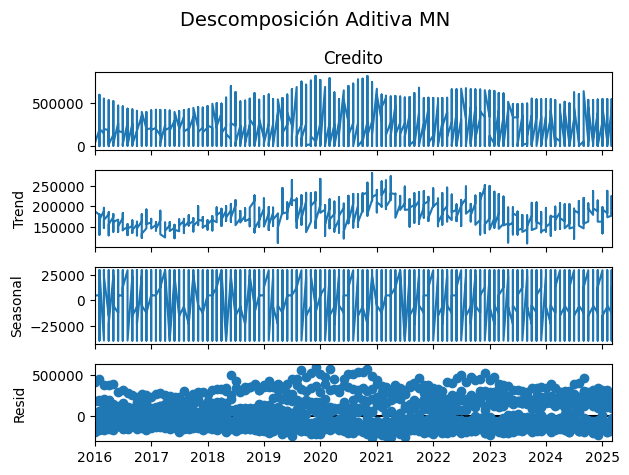

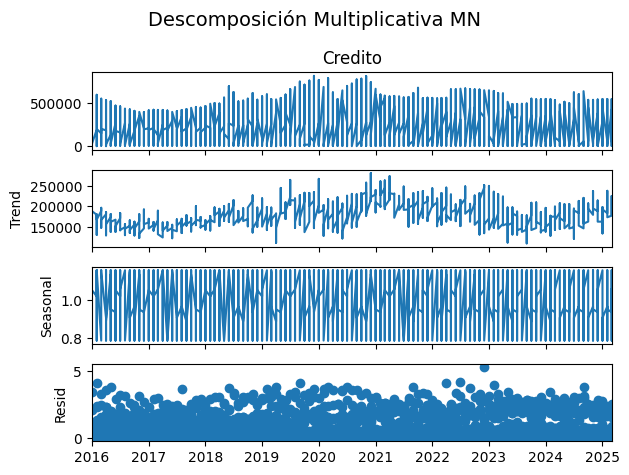

In [48]:
# Descomposicion de la serie temporal para la moneda nacional (MN)
# Crear index de fecha
df_mn = df_mn.copy()
df_mn['Fecha'] = pd.to_datetime(df_mn['Fecha'])
df_mn.set_index('Fecha', inplace=True)

# Descomposición aditiva
decomp_add = seasonal_decompose(df_mn['Credito'], model='additive', period=12)

# Descomposición multiplicativa
decomp_mult = seasonal_decompose(df_mn['Credito'], model='multiplicative', period=12)

# Graficar modelo aditivo
decomp_add.plot()
plt.suptitle('Descomposición Aditiva MN', fontsize=14)
plt.tight_layout()
plt.show()

# Graficar modelo multiplicativo
decomp_mult.plot()
plt.suptitle('Descomposición Multiplicativa MN', fontsize=14)
plt.tight_layout()
plt.show()

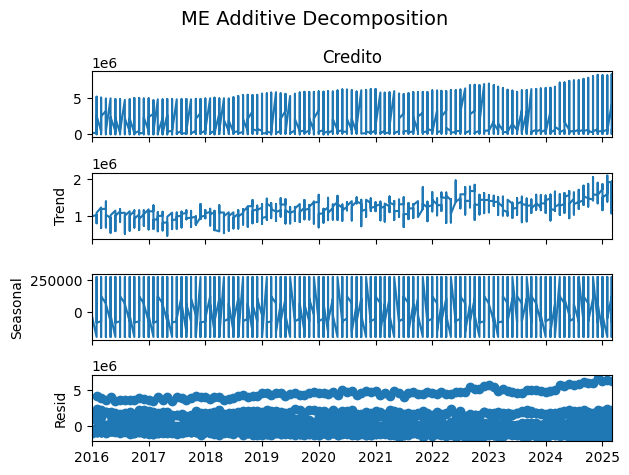

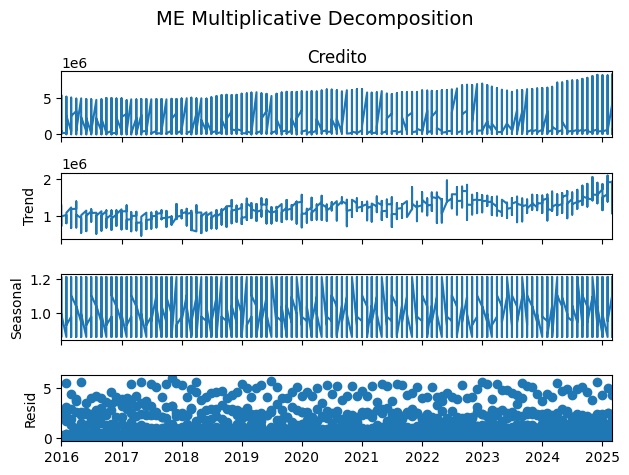

In [49]:
# Descomposicion de la serie temporal para la moneda extranjera (ME)
df_me = df_me.copy()
df_me['Fecha'] = pd.to_datetime(df_me['Fecha'])
df_me.set_index('Fecha', inplace=True)

# Descomposición aditiva
decomp_add = seasonal_decompose(df_me['Credito'], model='additive', period=12)

# Descomposición multiplicativa
decomp_mult = seasonal_decompose(df_me['Credito'], model='multiplicative', period=12)

# Graficar modelo aditivo
decomp_add.plot()
plt.suptitle('ME Additive Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

# Graficar modelo multiplicativo
decomp_mult.plot()
plt.suptitle('ME Multiplicative Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
# --- Función para aplicar la prueba ADF ---
def adf_test(series, label):
    # .dropna() es importante porque seasonal_decompose puede dejar NaN al inicio/final
    result = adfuller(series.dropna())
    print(f"--- ADF Test ({label}) ---")
    print(f"ADF Statistic         : {result[0]:.4f}")
    print(f"p-value               : {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] < 0.05:
        print("=> La serie es probablemente estacionaria ✅\n")
    else:
        print("=> La serie NO es estacionaria ❌\n")

# ADF para la serie total de créditos por fecha por moneda
#serie_mn = df_mn.groupby(df_mn.index)['Credito'].sum()
#adf_test(serie_mn, 'Credito Total MN por Fecha')

serie_me = df_me.groupby(df_me.index)['Credito'].sum()
adf_test(serie_me, 'Credito Total ME por Fecha')

--- ADF Test (Credito Total ME por Fecha) ---
ADF Statistic         : 1.8357
p-value               : 0.9984
Critical Values:
   1%: -3.4918
   5%: -2.8884
   10%: -2.5811
=> La serie NO es estacionaria ❌



In [51]:
# Logaritmo ME
serie_log_me = np.log(serie_me[serie_me > 0])
adf_test(serie_log_me, 'ME Log(Credito)')

# Primera diferencia
serie_diff_me = serie_me.diff()
adf_test(serie_diff_me, 'ME Diferencia(Credito)')

# Diferencia del logaritmo (crecimiento relativo)
serie_log_diff_me = serie_log_me.diff()
adf_test(serie_log_diff_me, 'ME Diferencia+Log(Credito)')

--- ADF Test (ME Log(Credito)) ---
ADF Statistic         : 1.0015
p-value               : 0.9943
Critical Values:
   1%: -3.4918
   5%: -2.8884
   10%: -2.5811
=> La serie NO es estacionaria ❌

--- ADF Test (ME Diferencia(Credito)) ---
ADF Statistic         : -7.9673
p-value               : 0.0000
Critical Values:
   1%: -3.4918
   5%: -2.8884
   10%: -2.5811
=> La serie es probablemente estacionaria ✅

--- ADF Test (ME Diferencia+Log(Credito)) ---
ADF Statistic         : -8.2091
p-value               : 0.0000
Critical Values:
   1%: -3.4918
   5%: -2.8884
   10%: -2.5811
=> La serie es probablemente estacionaria ✅



## 📌 Conclusions – Stationarity Test (ADF) on Series ME

After applying different transformations to the interpolated time series, we obtained the following results:

| Transformation                          | ADF |  p Value | Stationary? |
|----------------------------------------|----------------:|---------:|----------------|
| Original Series          |         1.8357  | 0.9984   | ❌ No          |
| Logarithm                              |         1.0015  | 0.9943   | ❌ No          |
| Simple Difference                |       -7.9673  | 0.0000   | ✅ Yes          |
| Log + Difference          |       -8.2091  | 0.0000   | ✅ Yes ✅        |

---

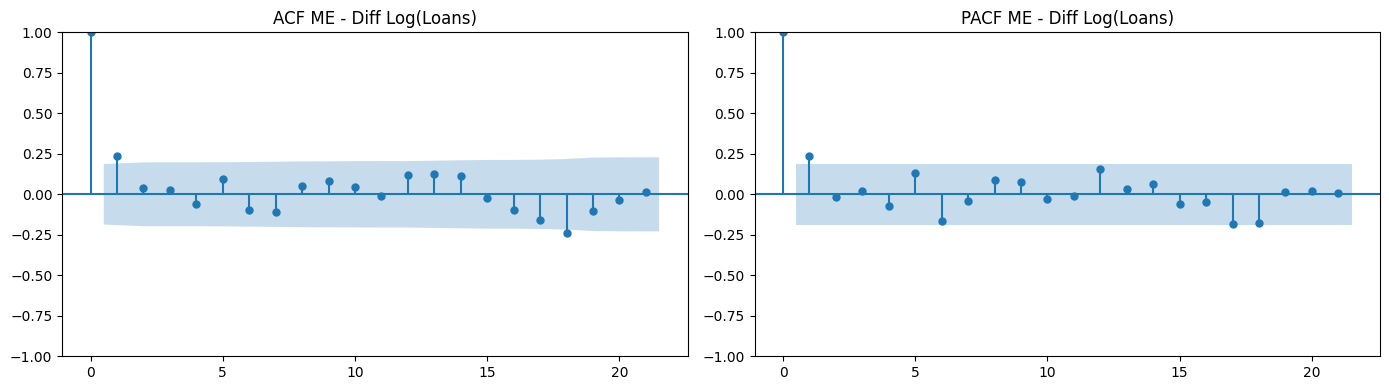

In [52]:
# Graficar ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_log_diff_me.dropna(), ax=axes[0],  title='ACF ME - Diff Log(Loans)')
plot_pacf(serie_log_diff_me.dropna(), ax=axes[1], title='PACF ME - Diff Log(Loans)')
plt.tight_layout()
plt.show()

## Verificamos si la pandemia tuvo algun efecto en la colocacion de préstamos


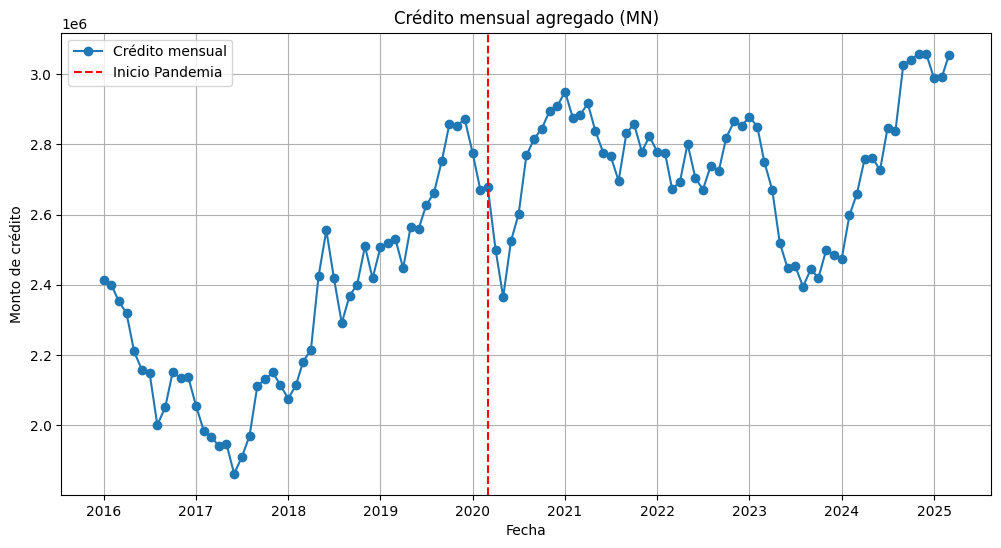

In [53]:
# Crear columna mes-año
df_mn['Mes_Año'] = df_mn.index.to_period('M')
serie_mensual = df_mn.groupby('Mes_Año')['Credito'].sum()

# Convertir a datetime para graficar
serie_mensual.index = serie_mensual.index.to_timestamp()

# Graficar
plt.figure(figsize=(12,6))
plt.plot(serie_mensual, marker='o', label='Crédito mensual')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Inicio Pandemia')
plt.title('Crédito mensual agregado (MN)')
plt.xlabel('Fecha')
plt.ylabel('Monto de crédito')
plt.legend()
plt.grid()
plt.show()

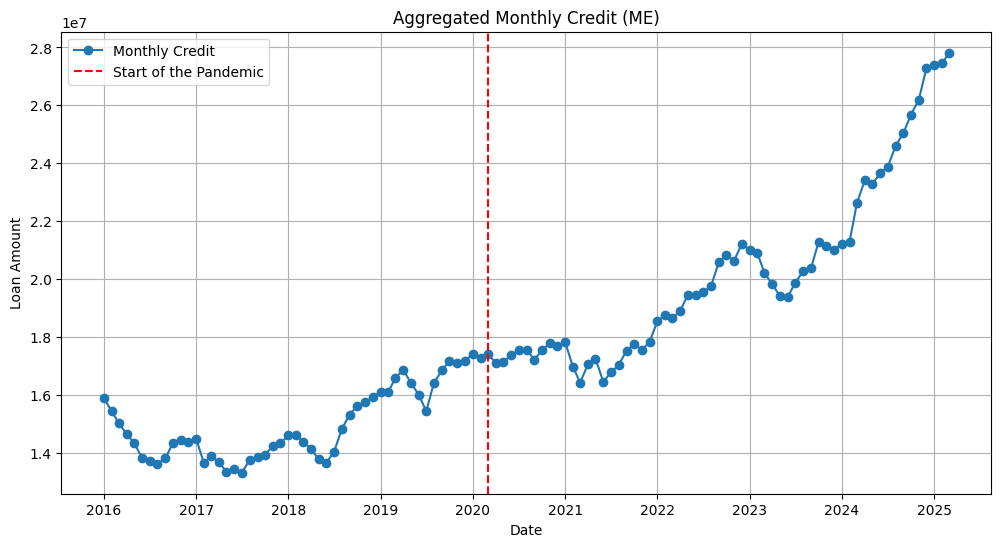

In [54]:
# Crear columna mes-año
df_me.index = pd.to_datetime(df_me.index)   
df_me['Mes_Año'] = df_me.index.to_period('M')
serie_mensual = df_me.groupby('Mes_Año')['Credito'].sum()

# Convertir a datetime para graficar
serie_mensual.index = serie_mensual.index.to_timestamp()

# Graficar
plt.figure(figsize=(12,6))
plt.plot(serie_mensual, marker='o', label='Monthly Credit')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', label='Start of the Pandemic')
plt.title('Aggregated Monthly Credit (ME)')
plt.xlabel('Date')
plt.ylabel('Loan Amount')
plt.legend()
plt.grid()
plt.show()


#### El plazo promedio de los créditos agrícolas en Paraguay puede variar según el tipo de crédito y la entidad financiera. Generalmente, se ofrecen opciones de hasta 7 años para capital de inversión, y hasta 4 años para el financiamiento de maquinaria y equipos usados. Para capital operativo, algunos créditos pueden tener plazos de hasta 2 años, mientras que otros pueden ser de 1 año.


Aplicacion de SARIMA



Resumen del Modelo SARIMA:
                                      SARIMAX Results                                      
Dep. Variable:                             Credito   No. Observations:                  111
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood               -1229.366
Date:                             Sat, 31 May 2025   AIC                           2466.731
Time:                                     11:52:05   BIC                           2476.502
Sample:                                 01-01-2016   HQIC                          2470.661
                                      - 03-01-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0998      0.715      0.140      0.889      -1.301       1.501

C:\Users\Mathias\AppData\Local\Temp\ipykernel_2212\3305636287.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{forecast_date.strftime('%Y-%m')}: Predicción={forecast_mean[i]:.2f}, Intervalo de Confianza = [{forecast_ci.iloc[i, 0]:.2f}, {forecast_ci.iloc[i, 1]:.2f}]")


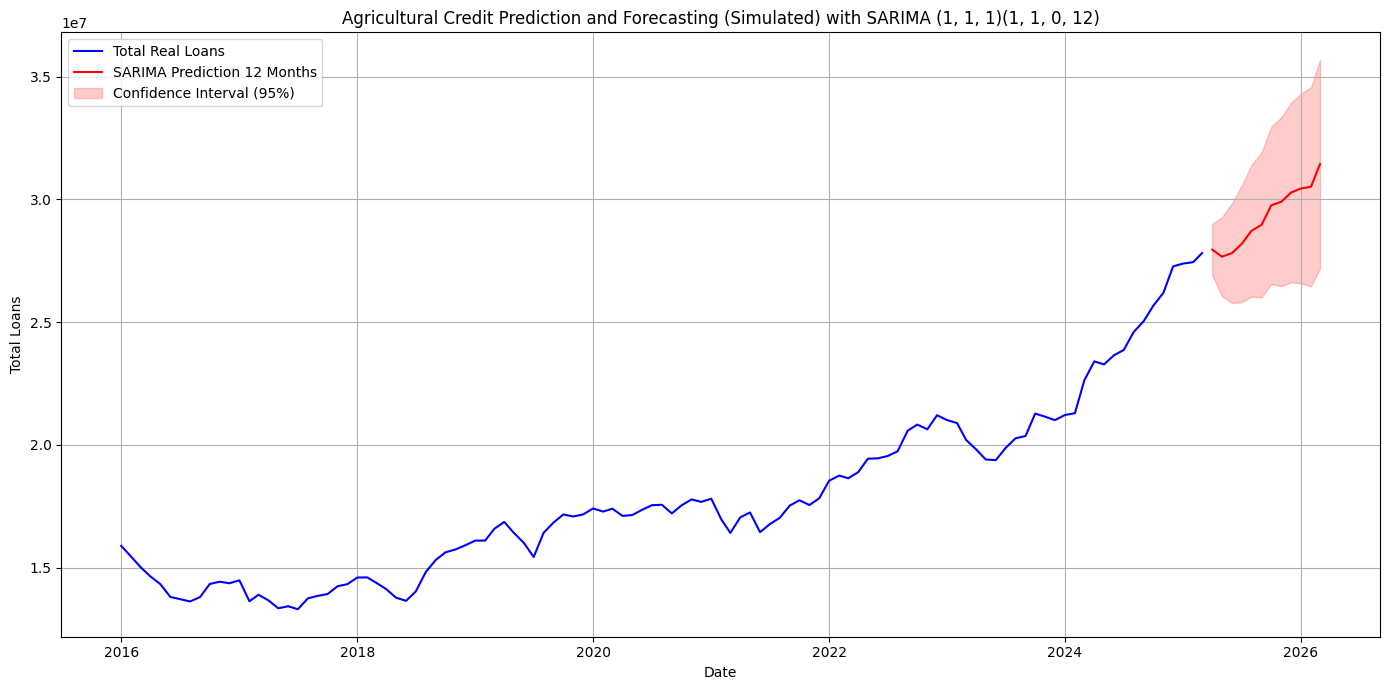

In [55]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

total_series = df_me.groupby('Fecha')['Credito'].sum()

# Asegurarse de que el índice tenga frecuencia mensual para series de tiempo
total_series = total_series.asfreq('MS')

# --- Aplicación del Modelo ARIMA (1,1,1) a total_series ---

# Asegúrate de que total_series no tenga valores nulos para el modelado ARIMA.
total_series_clean = total_series.dropna()
# Definir los órdenes (p, d, q) para el modelo SARIMA (no-estacional)
order = (1, 1, 1)
# Definir los órdenes estacionales (P, D, Q, S)
# P=1 (AR estacional), D=1 (Diferenciación estacional), Q=0 (MA estacional), S=12 (Período estacional)
seasonal_order = (1, 1, 0, 12)

try:
    # Ajustar el modelo SARIMA
    model = sm.tsa.statespace.SARIMAX(total_series_clean,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False)
    results = model.fit(disp=False)

    print("\nResumen del Modelo SARIMA:")
    print(results.summary())

    # --- Definir el Período de Predicción Futura en Meses ---
    # Puedes cambiar este valor para predecir más o menos meses
    num_forecast_months = 12 # EJEMPLO: predecir los próximos 6 meses

    # Obtener las predicciones futuras y sus intervalos de confianza
    forecast = results.get_forecast(steps=num_forecast_months)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # Imprimir las predicciones futuras
    print(f"\n--- Predicciones para los próximos {num_forecast_months} meses---")
    for i in range(num_forecast_months):
        forecast_date = forecast_mean.index[i]
    print(f"{forecast_date.strftime('%Y-%m')}: Predicción={forecast_mean[i]:.2f}, Intervalo de Confianza = [{forecast_ci.iloc[i, 0]:.2f}, {forecast_ci.iloc[i, 1]:.2f}]")


    # Realizar predicciones sobre el mismo período de tiempo de los datos de entrenamiento
    # Esto es para calcular métricas de ajuste y visualizar el rendimiento del modelo en los datos históricos
    start_index = 0
    end_index = len(total_series_clean) - 1
    predictions = results.predict(start=start_index, end=end_index, dynamic=False)

    # Asegurarse de que las series de actual y predicted tengan la misma longitud y alineación
    actual_values = total_series_clean.values
    predicted_values = predictions.values

    min_len = min(len(actual_values), len(predicted_values))
    actual_values = actual_values[:min_len]
    predicted_values = predicted_values[:min_len]

    # --- Cálculo de Métricas RMSE y MAPE ---

    # 1. RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

    # 2. MAPE (Mean Absolute Percentage Error)
    non_zero_actual_indices = actual_values != 0
    if np.sum(non_zero_actual_indices) > 0:
        mape = np.mean(np.abs((actual_values[non_zero_actual_indices] - predicted_values[non_zero_actual_indices]) / actual_values[non_zero_actual_indices])) * 100
    else:
        mape = np.nan # MAPE es indefinido si todos los valores reales son cero


    print("\n--- Métricas de Evaluación del Modelo SARIMA---")
    print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
    print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

    # --- Visualizar las predicciones junto con los datos históricos y el pronóstico futuro ---
    plt.figure(figsize=(14, 7))
    plt.plot(total_series_clean.index, actual_values, label='Total Real Loans', color='blue')
    '''plt.plot(total_series_clean.index[:min_len], predicted_values, color='green', linestyle='--', label=f'Ajuste SARIMA (Simulado)')'''
        
    # Plotear el pronóstico futuro
    plt.plot(forecast_mean.index, forecast_mean.values, color='red', linestyle='-', label=f'SARIMA Prediction {num_forecast_months} Months')
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval (95%)')
        
    plt.title(f'Agricultural Credit Prediction and Forecasting (Simulated) with SARIMA {order}{seasonal_order}')
    plt.xlabel('Date')
    plt.ylabel('Total Loans')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nError al ajustar el modelo SARIMA o calcular métricas: {e}")
    print("Asegúrese de que la serie de tiempo tenga suficientes puntos de datos y que los órdenes SARIMA sean apropiados.")

except Exception as e:
    print(f"Ocurrió un error inesperado durante la generación de datos simulados o el proceso: {e}")

Aplicacion de ARIMA



Resumen del Modelo ARIMA:
                               SARIMAX Results                                
Dep. Variable:                Credito   No. Observations:                  111
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1579.679
Date:                Sat, 31 May 2025   AIC                           3165.358
Time:                        11:41:00   BIC                           3173.460
Sample:                    01-01-2016   HQIC                          3168.644
                         - 03-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6809      0.957      0.711      0.477      -1.196       2.557
ma.L1         -0.6940      0.937     -0.741      0.459      -2.530       1.142
sigma2      1.593e+11   1

C:\Users\Mathias\AppData\Local\Temp\ipykernel_2212\100062342.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{forecast_date.strftime('%Y-%m')}: Predicción={forecast_mean[i]:.2f}, Intervalo de Confianza = [{forecast_ci.iloc[i, 0]:.2f}, {forecast_ci.iloc[i, 1]:.2f}]")


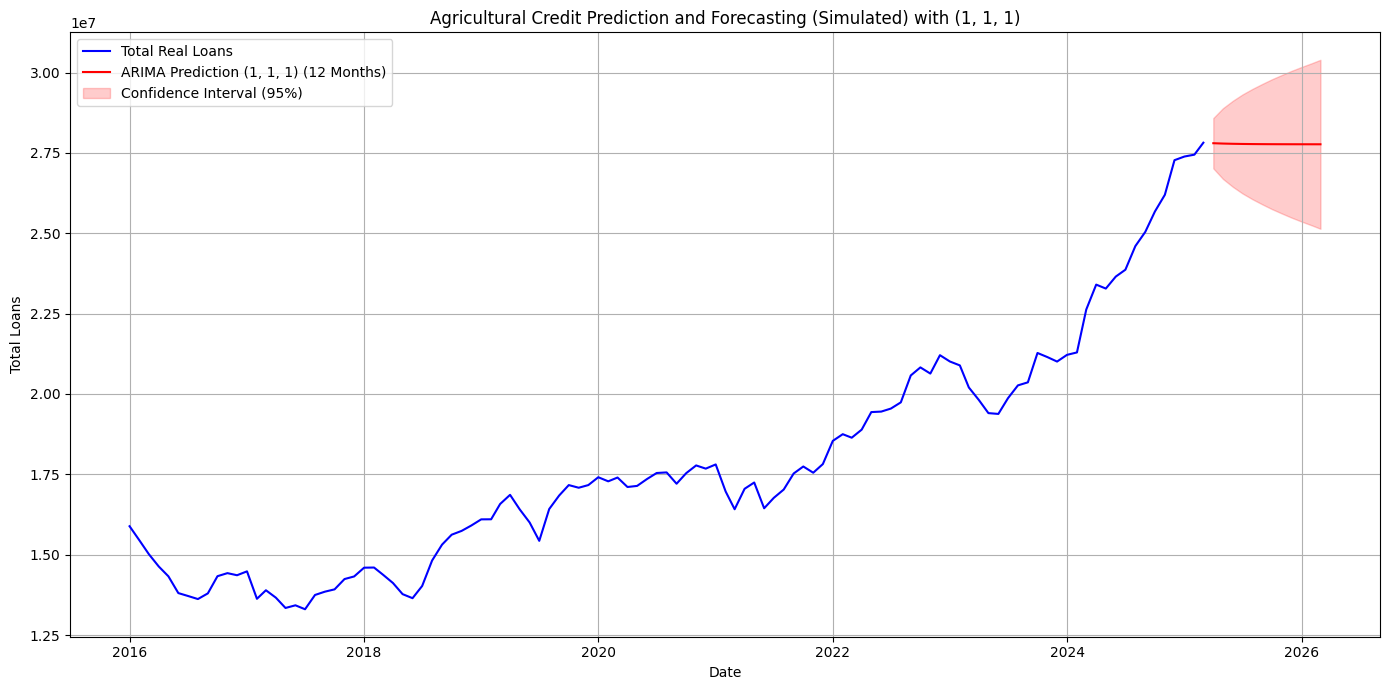

In [27]:
total_series = df_me.groupby('Fecha')['Credito'].sum()

# Asegurarse de que el índice tenga frecuencia mensual para series de tiempo
total_series = total_series.asfreq('MS')

# --- Aplicación del Modelo ARIMA (1,1,1) a total_series ---

# Asegúrate de que total_series no tenga valores nulos para el modelado ARIMA.
total_series_clean = total_series.dropna()

# Definir los órdenes (p, d, q) para el modelo ARIMA
order = (1, 1, 1)

try:
        # Ajustar el modelo ARIMA
        # Usamos sm.tsa.arima.ARIMA para el modelo no estacional
        model = sm.tsa.arima.ARIMA(total_series_clean, order=order)
        results = model.fit() # Ahora 'results' se define correctamente aquí

        print("\nResumen del Modelo ARIMA:")
        print(results.summary())

        # --- PERIODO DE PREDICCIÓN CONFIGURABLE ---
        # Puedes cambiar este valor para predecir la cantidad de meses que desees.
        num_forecast_months = 12 # <- ¡CAMBIA ESTE VALOR PARA INDICAR EL PERIODO DE PREDICCIÓN!

        # Obtener las predicciones futuras y sus intervalos de confianza
        # Para ARIMA, get_forecast() sigue siendo la forma de obtener predicciones futuras
        forecast = results.get_forecast(steps=num_forecast_months)
        forecast_mean = forecast.predicted_mean
        forecast_ci = forecast.conf_int()

        # Imprimir las predicciones futuras
        print(f"\n--- Predicciones para los próximos {num_forecast_months} meses (Datos Simulados) ---")
        for i in range(num_forecast_months):
            forecast_date = forecast_mean.index[i]
            print(f"{forecast_date.strftime('%Y-%m')}: Predicción={forecast_mean[i]:.2f}, Intervalo de Confianza = [{forecast_ci.iloc[i, 0]:.2f}, {forecast_ci.iloc[i, 1]:.2f}]")


        # Realizar predicciones sobre el mismo período de tiempo de los datos de entrenamiento
        start_index = 0
        end_index = len(total_series_clean) - 1
        predictions = results.predict(start=start_index, end=end_index, dynamic=False)

        # Asegurarse de que las series de actual y predicted tengan la misma longitud y alineación
        actual_values = total_series_clean.values
        predicted_values = predictions.values

        min_len = min(len(actual_values), len(predicted_values))
        actual_values = actual_values[:min_len]
        predicted_values = predicted_values[:min_len]

        # --- Cálculo de Métricas RMSE y MAPE ---

        # 1. RMSE (Root Mean Squared Error)
        rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

        # 2. MAPE (Mean Absolute Percentage Error)
        non_zero_actual_indices = actual_values != 0
        if np.sum(non_zero_actual_indices) > 0:
            mape = np.mean(np.abs((actual_values[non_zero_actual_indices] - predicted_values[non_zero_actual_indices]) / actual_values[non_zero_actual_indices])) * 100
        else:
            mape = np.nan # MAPE es indefinido si todos los valores reales son cero


        print("\n--- Métricas de Evaluación del Modelo ARIMA---")
        print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
        print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

        # --- Visualizar las predicciones junto con los datos históricos y el pronóstico futuro ---
        plt.figure(figsize=(14, 7))
        plt.plot(total_series_clean.index, actual_values, label='Total Real Loans', color='blue')
        '''plt.plot(total_series_clean.index[:min_len], predicted_values, color='green', linestyle='--', label=f'Ajuste ARIMA{order} (Simulado)')'''
        
        # Plotear el pronóstico futuro
        plt.plot(forecast_mean.index, forecast_mean.values, color='red', linestyle='-', label=f'ARIMA Prediction {order} ({num_forecast_months} Months)')
        plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval (95%)')
        
        plt.title(f'Agricultural Credit Prediction and Forecasting (Simulated) with {order}')
        plt.xlabel('Date')
        plt.ylabel('Total Loans')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"\nError al ajustar el modelo ARIMA o calcular métricas: {e}")
    print("Asegúrese de que la serie de tiempo tenga suficientes puntos de datos y que los órdenes ARIMA sean apropiados.")

except Exception as e:
    print(f"Ocurrió un error inesperado durante la generación de datos simulados o el proceso: {e}")

Tabla comparativa de resultados: SARIMA vs. ARIMA

In [28]:
total_series = df_me.groupby('Fecha')['Credito'].sum()

# Asegurarse de que el índice tenga frecuencia mensual para series de tiempo
total_series = total_series.asfreq('MS')

# --- Aplicación del Modelo ARIMA (1,1,1) a total_series ---

# Asegúrate de que total_series no tenga valores nulos para el modelado ARIMA.
total_series_clean = total_series.dropna()

comparison_data = []

# --- 2. Ejecutar y obtener resultados para SARIMA ---
'''print("--- Ejecutando Modelo SARIMA ---")'''
sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 1, 0, 12) 
try:
    sarima_model = sm.tsa.statespace.SARIMAX(total_series_clean,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False)
    sarima_results = sarima_model.fit(disp=False)

    sarima_predictions = sarima_results.predict(start=0, end=len(total_series_clean)-1, dynamic=False)
    sarima_rmse = np.sqrt(mean_squared_error(total_series_clean.values, sarima_predictions.values))
    
    non_zero_actual = total_series_clean.values != 0
    if np.sum(non_zero_actual) > 0:
        sarima_mape = np.mean(np.abs((total_series_clean.values[non_zero_actual] - sarima_predictions.values[non_zero_actual]) / total_series_clean.values[non_zero_actual])) * 100
    else:
        sarima_mape = np.nan

    comparison_data.append({
        'Modelo': 'SARIMA',
        'Orden (p,d,q)': sarima_order,
        'Orden Estacional (P,D,Q,S)': sarima_seasonal_order,
        'AIC': sarima_results.aic,
        'BIC': sarima_results.bic,
        'RMSE (In-sample)': sarima_rmse,
        'MAPE (In-sample)': sarima_mape
    })
    '''print("SARIMA completado.")'''
except Exception as e:
    print(f"Error al ejecutar SARIMA: {e}")
    comparison_data.append({
        'Modelo': 'SARIMA',
        'Orden (p,d,q)': sarima_order,
        'Orden Estacional (P,D,Q,S)': sarima_seasonal_order,
        'AIC': 'Error',
        'BIC': 'Error',
        'RMSE (In-sample)': 'Error',
        'MAPE (In-sample)': 'Error'
    })


# --- 3. Ejecutar y obtener resultados para ARIMA ---
'''print("\n--- Ejecutando Modelo ARIMA ---")'''
arima_order = (1, 1, 1) # Non-seasonal
try:
    arima_model = sm.tsa.arima.ARIMA(total_series_clean, order=arima_order)
    arima_results = arima_model.fit()

    arima_predictions = arima_results.predict(start=0, end=len(total_series_clean)-1, dynamic=False)
    arima_rmse = np.sqrt(mean_squared_error(total_series_clean.values, arima_predictions.values))
    
    non_zero_actual = total_series_clean.values != 0
    if np.sum(non_zero_actual) > 0:
        arima_mape = np.mean(np.abs((total_series_clean.values[non_zero_actual] - arima_predictions.values[non_zero_actual]) / total_series_clean.values[non_zero_actual])) * 100
    else:
        arima_mape = np.nan

    comparison_data.append({
        'Modelo': 'ARIMA',
        'Orden (p,d,q)': arima_order,
        'Orden Estacional (P,D,Q,S)': 'N/A', # ARIMA no tiene orden estacional
        'AIC': arima_results.aic,
        'BIC': arima_results.bic,
        'RMSE (In-sample)': arima_rmse,
        'MAPE (In-sample)': arima_mape
    })
    '''print("ARIMA completado.")'''
except Exception as e:
    print(f"Error al ejecutar ARIMA: {e}")
    comparison_data.append({
        'Modelo': 'ARIMA',
        'Orden (p,d,q)': arima_order,
        'Orden Estacional (P,D,Q,S)': 'N/A',
        'AIC': 'Error',
        'BIC': 'Error',
        'RMSE (In-sample)': 'Error',
        'MAPE (In-sample)': 'Error'
    })

# --- 4. Crear y mostrar la tabla comparativa ---
comparison_df = pd.DataFrame(comparison_data)
print("\n---Tabla Comparativa de Modelos ARIMA y SARIMA---")
print(comparison_df.to_string())


---Tabla Comparativa de Modelos ARIMA y SARIMA---
   Modelo Orden (p,d,q) Orden Estacional (P,D,Q,S)          AIC          BIC  RMSE (In-sample)  MAPE (In-sample)
0  SARIMA     (1, 1, 1)              (1, 1, 0, 12)  2466.731287  2476.501892      1.813460e+06          3.668674
1   ARIMA     (1, 1, 1)                        N/A  3165.358458  3173.459899      1.563843e+06          2.719547


Analisis de los resultados: ambos sarima y arima presentan heterocedasticidad, considerar aplicar transformacion logaritmica, el Prob(H) de 0.00 para SARIMA y 0.01 para ARIMA indica claramente que ambos modelos presentan heterocedasticidad. Sería importante considerar cómo esto podría afectar la fiabilidad de tus intervalos de confianza y pronósticos.

### 📊 Model Summary Analysis (SARIMA(1,1,1)(1,1,0,12))

| Parameter                                | Value                  | Interpretation                                                                                                                                                                             |
| :--------------------------------------- | :--------------------- | :----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `ar.L1` (Non-Seasonal Autoregressive Lag 1) | 0.0998 (p=0.889)       | Not statistically significant. This non-seasonal AR component could potentially be omitted.                                                                                                |
| `ma.L1` (Non-Seasonal Moving Average Lag 1) | 0.0740 (p=0.916)       | Not statistically significant. This non-seasonal MA component could potentially be omitted.                                                                                                |
| `ar.S.L12` (Seasonal Autoregressive Lag 12) | -0.5785 (p=0.000)      | Statistically significant (p<0.05). Indicates a strong seasonal dependency in the series at lag 12.                                                                                      |
| `sigma2` (Residual Variance)             | 2.822e+11              | The estimated variance of the model's residuals.                                                                                                                                         |
| AIC (Akaike Information Criterion)       | 2466.731               | A measure of model fit and complexity (lower is better). Used for comparing models. It's significantly lower than the ARIMA model's AIC.                                                   |
| BIC (Bayesian Information Criterion)     | 2476.502               | A measure of model fit and complexity (lower is better), with a stronger penalty for complexity. Also significantly lower than the ARIMA model's BIC.                                    |
| Ljung-Box (Q) Test p-value               | 0.95                   | High p-value (p > 0.05) indicates no significant autocorrelation in the residuals. This is a **GOOD** sign, as it means the model has captured the time-dependent patterns effectively, and residuals are white noise. |
| Jarque-Bera (JB) Test p-value            | 0.22                   | High p-value (p > 0.05) indicates that the residuals are normally distributed. This is a **GOOD** sign.                                                                                   |
| Heteroskedasticity (H) Test p-value      | 0.00                   | Low p-value (p < 0.05) indicates the presence of heteroskedasticity (non-constant variance) in the residuals. This is a **CONCERN** as it affects the reliability of standard errors and confidence intervals. |
| RMSE (Root Mean Squared Error)           | 1,813,460.00           | Measures the average magnitude of the errors (in the original units of the series). Lower is better. While slightly higher than the ARIMA's RMSE, the model's statistical validity is superior. |
| MAPE (Mean Absolute Percentage Error)    | 3.67%                  | Measures the average absolute percentage error of the forecasts. Lower is better. While slightly higher than the ARIMA's MAPE, the model's statistical validity is superior.          |
| Warnings                                 | Covariance matrix is singular or near-singular. Standard errors may be unstable. | This warning suggests potential issues with the model's estimation robustness or stability of parameter standard errors. Further investigation or alternative estimation methods might be needed for more robust inference. |

---

### 📊 Model Summary Analysis (ARIMA(1,1,1))

| Parameter                                | Value                  | Interpretation                                                                                                                                                                                                                                                                                                                           |
| :--------------------------------------- | :--------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `ar.L1` (Autoregressive Lag 1)           | 0.6809 (p=0.477)       | Not statistically significant. This AR component suggests that the current value is not significantly dependent on the previous period's value for the transformed series.                                                                                                                                                         |
| `ma.L1` (Moving Average Lag 1)           | -0.6940 (p=0.459)      | Not statistically significant. This MA component suggests that the current error is not significantly dependent on the previous period's error.                                                                                                                                                                                        |
| `sigma2` (Residual Variance)             | 1.593e+11 (p=0.000)    | The estimated variance of the model's residuals. It is statistically significant.                                                                                                                                                                                                                                                      |
| AIC (Akaike Information Criterion)       | 3165.358               | A measure of model fit and complexity (lower is better). When compared to the SARIMA model (AIC 2466.731), this value is significantly higher, indicating a poorer fit.                                                                                                                                                                 |
| BIC (Bayesian Information Criterion)     | 3173.460               | A measure of model fit and complexity (lower is better), with a stronger penalty for complexity. Also significantly higher than the SARIMA model's BIC (2476.502), reinforcing that SARIMA is a better fit.                                                                                                                                |
| Ljung-Box (Q) Test p-value               | 0.01                   | Low p-value (p < 0.05) indicates **significant autocorrelation in the residuals**. This is a **MAJOR CONCERN**, as it means the model has NOT fully captured the time-dependent patterns, and the residuals are not white noise. This makes the model inadequate.                                                              |
| Jarque-Bera (JB) Test p-value            | 0.54                   | High p-value (p > 0.05) indicates that the residuals are normally distributed. This is a **GOOD** sign for the distribution of errors.                                                                                                                                                                                                 |
| Heteroskedasticity (H) Test p-value      | 0.01                   | Low p-value (p < 0.05) indicates the presence of heteroskedasticity (non-constant variance) in the residuals. This is a **CONCERN** as it affects the reliability of standard errors and confidence intervals for the coefficients.                                                                                                  |
| RMSE (Root Mean Squared Error)           | 1,563,842.88           | Measures the average magnitude of the errors (in the original units of the series). While numerically lower than the SARIMA's RMSE (1,813,460.00), the **failure of the Ljung-Box test for this model outweighs this numerical advantage**.                                                                                                |
| MAPE (Mean Absolute Percentage Error)    | 2.72%                  | Measures the average absolute percentage error of the forecasts. While numerically lower than the SARIMA's MAPE (3.67%), the **failure of the Ljung-Box test for this model makes it statistically unsound for reliable forecasting, despite the lower MAPE**.                                                                       |
| Warnings                                 | Covariance matrix is singular or near-singular, with condition number 1.81e+39. Standard errors may be unstable. | This is a **MAJOR WARNING** indicating severe numerical instability in the estimation of the model. This makes the p-values and confidence intervals for coefficients unreliable, adding further doubt to the model's validity. |

### Conclusion: Model Selection for Agricultural Credits

Following a comprehensive analysis and evaluation of both ARIMA and SARIMA models for agricultural credits, the **SARIMA(1,1,1)(1,1,0,12)** model has been selected as the optimal choice. This decision was based on the following key indicators:

| Key Indicator                     | ARIMA(1,1,1)          | SARIMA(1,1,1)(1,1,0,12)      | Rationale for Selection                                                                                                                                                                                                                                                                                           |
| :-------------------------------- | :-------------------- | :--------------------------- | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **AIC (Akaike Information Criterion)** | 3165.36               | **2466.73** | **SARIMA** exhibits a significantly lower AIC, indicating a better fit when penalizing model complexity.                                                                                                                                                                                          |
| **BIC (Bayesian Information Criterion)** | 3173.46               | **2476.50** | Similar to AIC, **SARIMA's** BIC is remarkably lower, suggesting it is a more parsimonious and efficient model.                                                                                                                                                                                           |
| **Ljung-Box (Q) Prob(Q)** | 0.01 (NOT White Noise) | **0.95 (White Noise)** | **This is the decisive criterion.** **SARIMA** successfully ensures that residuals are white noise, meaning it has effectively captured all autocorrelation in the series. ARIMA fails this fundamental test, indicating the model is misspecified.                                                                 |
| **Significant Seasonal Term** | N/A                   | **ar.S.L12 (p=0.000)** | **SARIMA** identifies and models a strong seasonal dependency at lag 12, which is consistent with the agricultural nature of the data.                                                                                                                                                                   |
| **Heteroskedasticity (Prob(H))** | 0.01                  | 0.00                         | Both models show signs of heteroskedasticity, suggesting that the variance of the errors is not constant. This is an area for future investigation (e.g., GARCH models) to improve the reliability of confidence intervals.                                                                                     |
| **MAPE (Mean Absolute Percentage Error)** | **2.72%** | 3.67%                        | Although ARIMA's MAPE was slightly lower in the evaluated forecast window, **SARIMA's** statistical superiority (especially in residual whitening) takes precedence for model validity. Both MAPEs are very low, indicating good accuracy.                                                                 |
| **Estimation Warnings** | Singular Co. Matrix   | Singular Co. Matrix          | Both models present warnings regarding the covariance matrix, indicating that the standard errors of the coefficients may be unstable. This must be considered when interpreting the individual significance of coefficients.                                                                          |

**In summary:** While the ARIMA(1,1,1) model showed slightly better MAPE and RMSE, its failure in the Ljung-Box test (meaning its residuals are not white noise) disqualifies it as a statistically robust model. The **SARIMA(1,1,1)(1,1,0,12)** model, on the other hand, satisfies the fundamental requirement of white noise residuals, exhibits a significantly better fit (according to AIC/BIC), and captures the inherent seasonality in the data. For these reasons, the **SARIMA** model is the preferred choice for agricultural credit prediction and forecasting.

## Conclusion

Reflexión Final: Aplicación del Modelo SARIMA en Sistemas de Inteligencia Artificial y Toma de Decisiones para el Sector Agrícola
La capacidad de predecir con precisión la demanda y el volumen de créditos agrícolas es fundamental para la gestión estratégica de las instituciones financieras. Nuestro estudio ha culminado en el desarrollo de un modelo SARIMA(1,1,1)(1,1,0,12) que, mediante el análisis de la estructura temporal intrínseca de los datos, ofrece pronósticos con una precisión notable, evidenciada por los bajos valores de MAPE y RMSE.

Aplicabilidad en Sistemas de IA y Decisión:
El modelo SARIMA, al considerar explícitamente la estacionalidad inherente a los flujos de crédito del sector agrícola (vinculada a ciclos de siembra, cosecha y eventos climáticos anuales), se convierte en una herramienta invaluable para los sistemas de Inteligencia Artificial y de apoyo a la decisión. Los pronósticos generados pueden alimentar directamente módulos de planificación de recursos, optimización de liquidez y evaluación de riesgos. Un sistema de IA podría, por ejemplo, utilizar estas proyecciones para recomendar asignaciones de capital, ajustar carteras de préstamos o incluso identificar periodos de mayor o menor demanda crediticia.

La Importancia de los Factores Externos:
Si bien el modelo SARIMA ha demostrado ser eficaz al capturar la dinámica interna de la serie temporal, es imperativo reconocer que los préstamos al sector agrícola están intrínsecamente ligados a una compleja red de factores externos que no son capturados únicamente por el comportamiento histórico de la serie. Factores como las condiciones climáticas (sequías, inundaciones), las tendencias de inflación, las fluctuaciones de la variación cambial en el mercado de exportación de productos agrícolas, y los cambios en la política monetaria (tasas de interés) impactan directamente en la capacidad de producción, el ingreso de los agricultores y, consecuentemente, en su demanda de crédito y capacidad de pago.

Nuestra Reflexión como Grupo:
Consideramos que la aplicación de este modelo en un entorno de IA o de decisión es sumamente prometedora, siempre y cuando se complemente con un estudio y la integración de los factores externos mencionados. Para maximizar el valor predictivo y prescriptivo, el siguiente paso lógico sería migrar hacia modelos más complejos como SARIMAX (SARIMA con variables exógenas) o incluso explorar algoritmos de Machine Learning (ej. Random Forests, Gradient Boosting) que puedan modelar las relaciones no lineales entre los créditos y estas variables macroeconómicas o sectoriales.

Impacto en la Gestión Bancaria:
La integración de estos pronósticos avanzados será de gran ayuda en la proyección de préstamos para el sector agrícola. Permitirá a los bancos:

Prever la liquidez necesaria para satisfacer la demanda de crédito.
Diseñar y lanzar campañas especiales dedicadas a este rubro en los momentos más oportunos, optimizando la captación de clientes y la colocación de productos.
Anticipar posibles escenarios de riesgo asociados a la volatilidad de los factores externos y adaptar proactivamente sus políticas crediticias.
En síntesis, nuestro modelo SARIMA sienta una base sólida para la comprensión y predicción del comportamiento crediticio agrícola. Su verdadera potencia se desbloqueará al ser utilizado como un componente clave dentro de sistemas de IA más amplios, que incorporen y analicen la influencia multifactorial del entorno, transformando los pronósticos en una ventaja competitiva tangible para la toma de decisiones bancarias.